In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from pandas.plotting import scatter_matrix
from utils import save_fig # extra code – function to save the figures as high-res PNGs for the book

In [2]:

df = pd.read_csv("cars.csv")

In [3]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


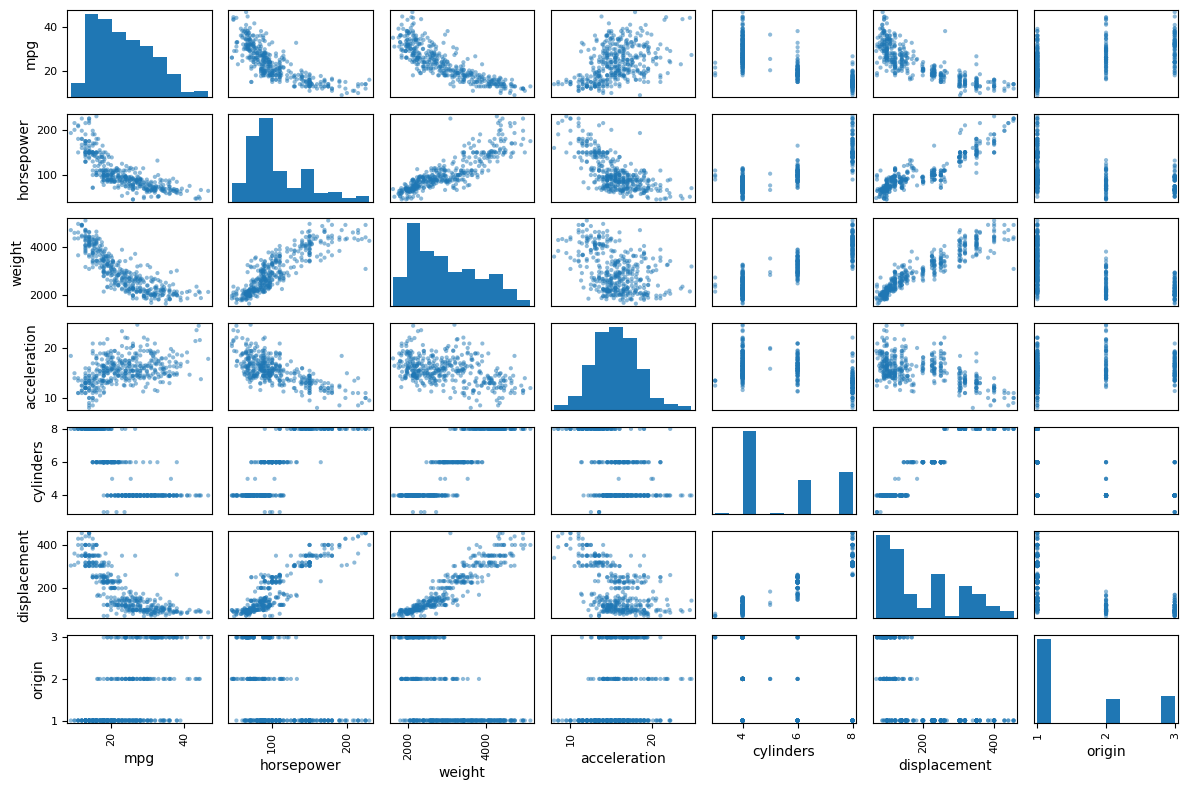

In [7]:
from pandas.plotting import scatter_matrix
from utils import save_fig # extra code – function to save the figures as high-res PNGs for the book


attributes = ["mpg", "horsepower", "weight",
              "acceleration", "cylinders", "displacement", "origin"]
scatter_matrix(df[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # extra code
plt.show()

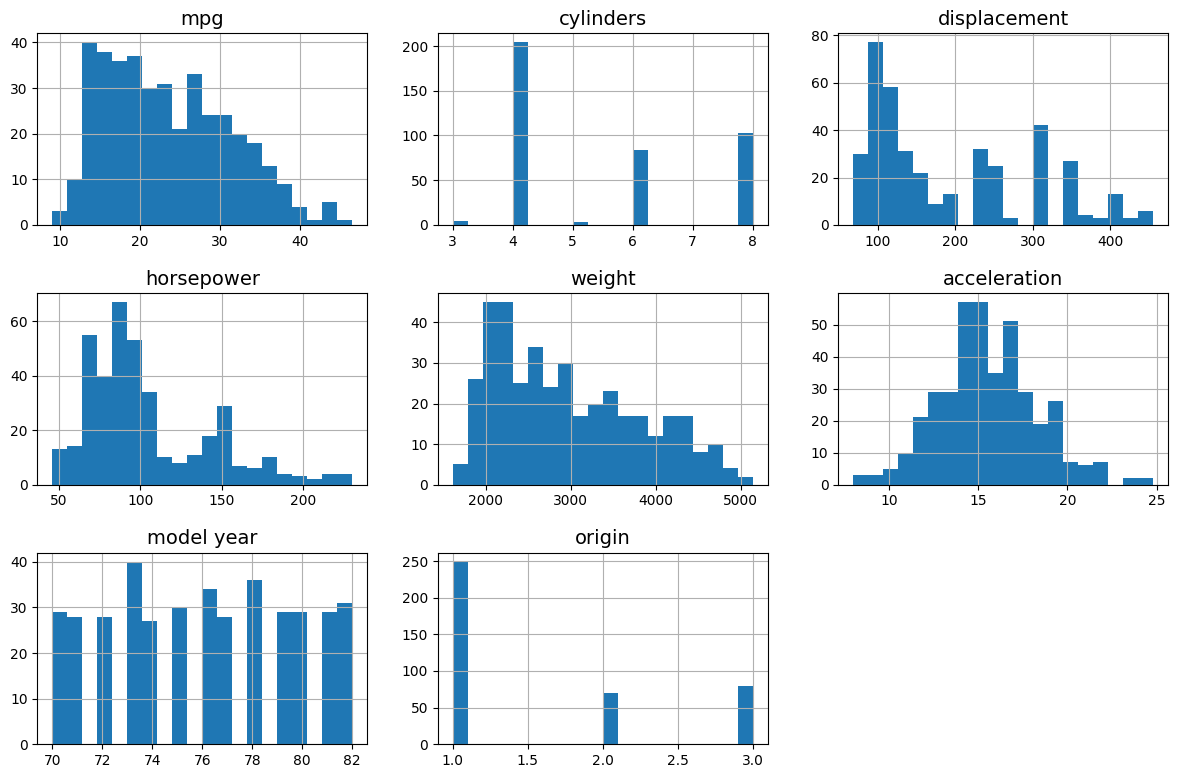

In [8]:
# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.hist(bins=20, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

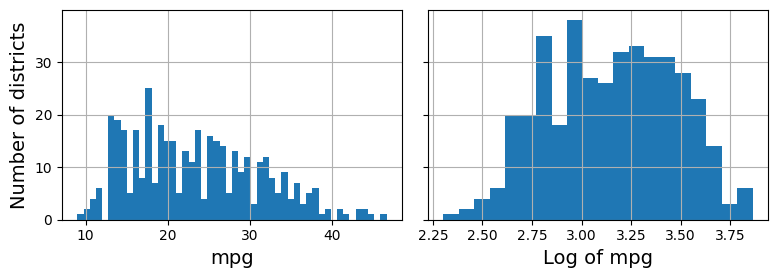

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
df["mpg"].hist(ax=axs[0], bins=50)
df["mpg"].apply(np.log1p).hist(ax=axs[1], bins=20)
axs[0].set_xlabel("mpg")
axs[1].set_xlabel("Log of mpg")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

In [10]:
df = df.drop(columns=["car name"])

In [11]:
df["horsepower"] = df.groupby("cylinders")["horsepower"]\
                     .transform(lambda x: x.fillna(x.mean()))

In [12]:
corr = df.corr(numeric_only=True)
print(corr["acceleration"].sort_values())

horsepower     -0.688022
displacement   -0.543684
cylinders      -0.505419
weight         -0.417457
origin          0.205873
model year      0.288137
mpg             0.420289
acceleration    1.000000
Name: acceleration, dtype: float64


In [13]:
corr = df.corr(numeric_only=True)
print(corr["horsepower"].sort_values())

mpg            -0.775608
acceleration   -0.688022
origin         -0.450352
model year     -0.416841
cylinders       0.843794
weight          0.863600
displacement    0.897520
horsepower      1.000000
Name: horsepower, dtype: float64


In [14]:
corr = df.corr(numeric_only=True)

for col in corr.columns:
    print(f"\nCorrelations with {col}:")
    print(corr[col].sort_values(ascending=False))


Correlations with mpg:
mpg             1.000000
model year      0.579267
origin          0.563450
acceleration    0.420289
cylinders      -0.775396
horsepower     -0.775608
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64

Correlations with cylinders:
cylinders       1.000000
displacement    0.950721
weight          0.896017
horsepower      0.843794
model year     -0.348746
acceleration   -0.505419
origin         -0.562543
mpg            -0.775396
Name: cylinders, dtype: float64

Correlations with displacement:
displacement    1.000000
cylinders       0.950721
weight          0.932824
horsepower      0.897520
model year     -0.370164
acceleration   -0.543684
origin         -0.609409
mpg            -0.804203
Name: displacement, dtype: float64

Correlations with horsepower:
horsepower      1.000000
displacement    0.897520
weight          0.863600
cylinders       0.843794
model year     -0.416841
origin         -0.450352
acceleration   -0.688022
mpg           

In [15]:
df["horsepower"] = df.groupby("cylinders")["horsepower"]\
                     .transform(lambda x: x.fillna(x.mean()))

In [16]:
corr = df.corr(numeric_only=True)
print(corr["horsepower"].sort_values())

mpg            -0.775608
acceleration   -0.688022
origin         -0.450352
model year     -0.416841
cylinders       0.843794
weight          0.863600
displacement    0.897520
horsepower      1.000000
Name: horsepower, dtype: float64


In [17]:
df = df.drop(columns=["origin"])
df = df.drop(columns=["model year"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 18.8 KB


In [19]:
labels = df.columns.values
print(labels)

['mpg' 'cylinders' 'displacement' 'horsepower' 'weight' 'acceleration']


In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -------- Load your dataframe --------
# df = pd.read_csv("your_file.csv")  # uncomment if needed

# -------- Define features and target --------
X = df.drop(columns=["horsepower"])   # predict mpg
y = df["horsepower"]

# -------- Train / Validation / Test split (70/15/15) --------
#X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
#X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# -------- Scaling (fit ONLY on training data) --------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# -------- Models --------
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, #Number of trees in the forest
        max_depth=10, #Maximum depth of the tree
        min_samples_split=5, #Minimum number of samples required to split an internal node
        random_state=42)
}

# -------- Evaluation function --------
def evaluate(model, X, y, dataset_name):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred) #R-squared
    rmse = np.sqrt(mean_squared_error(y, y_pred)) #Root mean squared error
    mae = mean_absolute_error(y, y_pred) #Mean absolute error
    print(f"{dataset_name} -> R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

# -------- Train + Evaluate --------
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Evaluate
    evaluate(model, X_train_scaled, y_train, "Train")
    evaluate(model, X_val_scaled, y_val, "Validation")
    evaluate(model, X_test_scaled, y_test, "Test")


===== Linear Regression =====
Train -> R2: 0.8799, RMSE: 12.5494, MAE: 9.1530
Validation -> R2: 0.8965, RMSE: 13.5705, MAE: 9.4813
Test -> R2: 0.8972, RMSE: 13.8671, MAE: 9.2609

===== Random Forest =====
Train -> R2: 0.9788, RMSE: 5.2736, MAE: 3.5722
Validation -> R2: 0.9387, RMSE: 10.4473, MAE: 8.3025
Test -> R2: 0.9018, RMSE: 13.5515, MAE: 9.2506


In [ ]:

# ========== RANDOMIZED SEARCH FOR HYPERPARAMETER TUNING ==========
import random
from sklearn.base import clone

# Define parameter distributions (more conservative to avoid overfitting)
param_distributions = {
    "Linear Regression": {
        "fit_intercept": [True, False],
        "positive": [True, False]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 150, 200],  # fewer options, more conservative
        "max_depth": [5, 8, 10, 12, 15],     # avoid None to prevent overfitting
        "min_samples_split": [5, 8, 10],      # higher values to prevent overfitting
        "min_samples_leaf": [2, 3, 4],        # higher values to prevent overfitting
        "max_features": ["sqrt", "log2"]
    }
}

# Manual randomized search that optimizes for validation performance
best_models = {}
random.seed(42)

for name, base_model in models.items():
    print(f"\n===== RandomizedSearch for {name} =====")

    param_space = param_distributions[name]
    param_names = list(param_space.keys())

    best_score = -float('inf')
    best_params = None
    best_model = None

    # Try 15 random combinations
    for i in range(30):
        # Sample random parameters
        params = {}
        for param_name in param_names:
            params[param_name] = random.choice(param_space[param_name])

        # Create and fit model with these parameters
        model = clone(base_model)
        model.set_params(**params)
        model.fit(X_train_scaled, y_train)

        # Evaluate on validation set
        y_val_pred = model.predict(X_val_scaled) #Predictions on validation set
        val_score = r2_score(y_val, y_val_pred) #R-squared on validation set

        # Keep track of best
        if val_score > best_score:
            best_score = val_score
            best_params = params.copy()
            best_model = model

    # Store best model and print results
    best_models[name] = best_model
    print(f"Best parameters: {best_params}")
    print(f"Best Validation Score: {best_score:.4f}")

    # Evaluate best model
    print(f"\n{name} - Best Model Performance:")
    evaluate(best_models[name], X_train_scaled, y_train, "Train")
    evaluate(best_models[name], X_val_scaled, y_val, "Validation")
    evaluate(best_models[name], X_test_scaled, y_test, "Test")



===== RandomizedSearch for Linear Regression =====
Best parameters: {'fit_intercept': True, 'positive': False}
Best Validation Score: 0.8965

Linear Regression - Best Model Performance:
Train -> R2: 0.8799, RMSE: 12.5494, MAE: 9.1530
Validation -> R2: 0.8965, RMSE: 13.5705, MAE: 9.4813
Test -> R2: 0.8972, RMSE: 13.8671, MAE: 9.2609

===== RandomizedSearch for Random Forest =====
Best parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}
Best Validation Score: 0.9323

Random Forest - Best Model Performance:
Train -> R2: 0.9644, RMSE: 6.8346, MAE: 4.6434
Validation -> R2: 0.9323, RMSE: 10.9804, MAE: 8.4611
Test -> R2: 0.9026, RMSE: 13.4998, MAE: 9.2650


**We are satisfied with our models evaluation scores, the fitness of the model is somewhat okay.  
We will save the random forest model for later use.**

In [24]:

# ========== RANDOMIZED SEARCH FOR HYPERPARAMETER TUNING ==========
import random
from sklearn.base import clone

# Define parameter distributions (more conservative to avoid overfitting)
param_distributions = {
    "Linear Regression": {
        "fit_intercept": [True, False],
        "positive": [True, False]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 150, 200],  # fewer options, more conservative
        "max_depth": [5, 8, 10, 12, 15],     # avoid None to prevent overfitting
        "min_samples_split": [5, 8, 10],      # higher values to prevent overfitting
        "min_samples_leaf": [2, 3, 4],        # higher values to prevent overfitting
        "max_features": ["sqrt", "log2"]
    }
}

# Manual randomized search that optimizes for validation performance
best_models = {}
random.seed(42)

for name, base_model in models.items():
    print(f"\n===== RandomizedSearch for {name} =====")

    param_space = param_distributions[name]
    param_names = list(param_space.keys())

    best_score = -float('inf')
    best_params = None
    best_model = None

    # Try 15 random combinations
    for i in range(15):
        # Sample random parameters
        params = {}
        for param_name in param_names:
            params[param_name] = random.choice(param_space[param_name])

        # Create and fit model with these parameters
        model = clone(base_model)
        model.set_params(**params)
        model.fit(X_train_scaled, y_train)

        # Evaluate on validation set
        y_val_pred = model.predict(X_val_scaled) #Predictions on validation set
        val_score = r2_score(y_val, y_val_pred) #R-squared on validation set

        # Keep track of best
        if val_score > best_score:
            best_score = val_score
            best_params = params.copy()
            best_model = model

    # Store best model and print results
    best_models[name] = best_model
    print(f"Best parameters: {best_params}")
    print(f"Best Validation Score: {best_score:.4f}")

    # Evaluate best model
    print(f"\n{name} - Best Model Performance:")
    evaluate(best_models[name], X_train_scaled, y_train, "Train")
    evaluate(best_models[name], X_val_scaled, y_val, "Validation")
    evaluate(best_models[name], X_test_scaled, y_test, "Test")



===== RandomizedSearch for Linear Regression =====
Best parameters: {'fit_intercept': True, 'positive': False}
Best Validation Score: 0.8965

Linear Regression - Best Model Performance:
Train -> R2: 0.8799, RMSE: 12.5494, MAE: 9.1530
Validation -> R2: 0.8965, RMSE: 13.5705, MAE: 9.4813
Test -> R2: 0.8972, RMSE: 13.8671, MAE: 9.2609

===== RandomizedSearch for Random Forest =====
Best parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}
Best Validation Score: 0.9323

Random Forest - Best Model Performance:
Train -> R2: 0.9644, RMSE: 6.8346, MAE: 4.6434
Validation -> R2: 0.9323, RMSE: 10.9804, MAE: 8.4611
Test -> R2: 0.9026, RMSE: 13.4998, MAE: 9.2650


In [25]:

# ========== RANDOMIZED SEARCH FOR HYPERPARAMETER TUNING ==========
import random
from sklearn.base import clone

# Define parameter distributions (more conservative to avoid overfitting)
param_distributions = {
    "Linear Regression": {
        "fit_intercept": [True, False],
        "positive": [True, False]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 150, 200],  # fewer options, more conservative
        "max_depth": [5, 8, 10, 12, 15],     # avoid None to prevent overfitting
        "min_samples_split": [5, 8, 10],      # higher values to prevent overfitting
        "min_samples_leaf": [2, 3, 4],        # higher values to prevent overfitting
        "max_features": ["sqrt", "log2"]
    }
}

# Manual randomized search that optimizes for validation performance
best_models = {}
random.seed(42)

for name, base_model in models.items():
    print(f"\n===== RandomizedSearch for {name} =====")

    param_space = param_distributions[name]
    param_names = list(param_space.keys())

    best_score = -float('inf')
    best_params = None
    best_model = None

    # Try 15 random combinations
    for i in range(60):
        # Sample random parameters
        params = {}
        for param_name in param_names:
            params[param_name] = random.choice(param_space[param_name])

        # Create and fit model with these parameters
        model = clone(base_model)
        model.set_params(**params)
        model.fit(X_train_scaled, y_train)

        # Evaluate on validation set
        y_val_pred = model.predict(X_val_scaled) #Predictions on validation set
        val_score = r2_score(y_val, y_val_pred) #R-squared on validation set

        # Keep track of best
        if val_score > best_score:
            best_score = val_score
            best_params = params.copy()
            best_model = model

    # Store best model and print results
    best_models[name] = best_model
    print(f"Best parameters: {best_params}")
    print(f"Best Validation Score: {best_score:.4f}")

    # Evaluate best model
    print(f"\n{name} - Best Model Performance:")
    evaluate(best_models[name], X_train_scaled, y_train, "Train")
    evaluate(best_models[name], X_val_scaled, y_val, "Validation")
    evaluate(best_models[name], X_test_scaled, y_test, "Test")



===== RandomizedSearch for Linear Regression =====
Best parameters: {'fit_intercept': True, 'positive': False}
Best Validation Score: 0.8965

Linear Regression - Best Model Performance:
Train -> R2: 0.8799, RMSE: 12.5494, MAE: 9.1530
Validation -> R2: 0.8965, RMSE: 13.5705, MAE: 9.4813
Test -> R2: 0.8972, RMSE: 13.8671, MAE: 9.2609

===== RandomizedSearch for Random Forest =====
Best parameters: {'n_estimators': 50, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Best Validation Score: 0.9333

Random Forest - Best Model Performance:
Train -> R2: 0.9656, RMSE: 6.7207, MAE: 4.5517
Validation -> R2: 0.9333, RMSE: 10.8950, MAE: 8.7159
Test -> R2: 0.8994, RMSE: 13.7169, MAE: 9.4887


In [22]:
models['Random Forest']

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
import joblib

joblib.dump(models['Random Forest'], "regression_model.pkl")

['regression_model.pkl']